# US Automotive Market Dynamics: Inventory, Sales, and Inflation (2024 – Present)

## US Vehicle Ecosystem: Supply Elasticity, Moving Averages, and Price Pressures

### Description

This notebook delivers a granular visual tracking of the contemporary U.S. automotive market landscape. Utilizing key datasets from the Federal Reserve Economic Data (FRED), the analysis synthesizes:

- **Auto Inventory to Sales Ratio (`AISRSA`):** Measures market balance showing how many months current vehicle stock can sustain ongoing sales volumes.
- **Domestic Vehicle Inventory (`AUINSA`):** Tracks raw unit volume additions to dealerships alongside a 3-month trailing moving average of monthly net changes.
- **Total Vehicle Sales (`TOTALSA`):** Quantifies consumer demand velocity measured at a seasonally adjusted annual rate (SAAR).
- **New Vehicle CPI Inflation (`CUSR0000SETA01`):** Captures real-time pricing power dynamics using the year-over-year consumer price percentage change.

---

## Objectives

- Assess post-2024 supply chain normalization via absolute inventory volumes vs. operational sales speeds.
- Isolate the momentum of vehicle demand shifts using a 3-month smoothed moving average delta.
- Contrast retail vehicle price shifts against physical dealer lot inventory trends to map supply-demand economic principles.

---

## Data Sources

- Federal Reserve Economic Data (FRED)
  - `AISRSA`: Domestic Auto Inventory to Sales Ratio (Monthly)
  - `AUINSA`: Domestic Vehicle Inventory (Monthly, Thousands)
  - `TOTALSA`: Total Vehicle Sales (Monthly, Millions, SAAR)
  - `CUSR0000SETA01`: Consumer Price Index for All Urban Consumers: New Vehicles (Monthly)

In [1]:
# Pandas external data reader
!pip install pandas-datareader


In [2]:
# Imports

# data manipulation
import numpy as np
import pandas as pd
import pandas_datareader.data as web

# datetime functions
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

# data visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [3]:
start = datetime(2024, 1, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(years=1)

### U.S. Domestic Auto Inventory to Sales Ratio (2024 - Present)

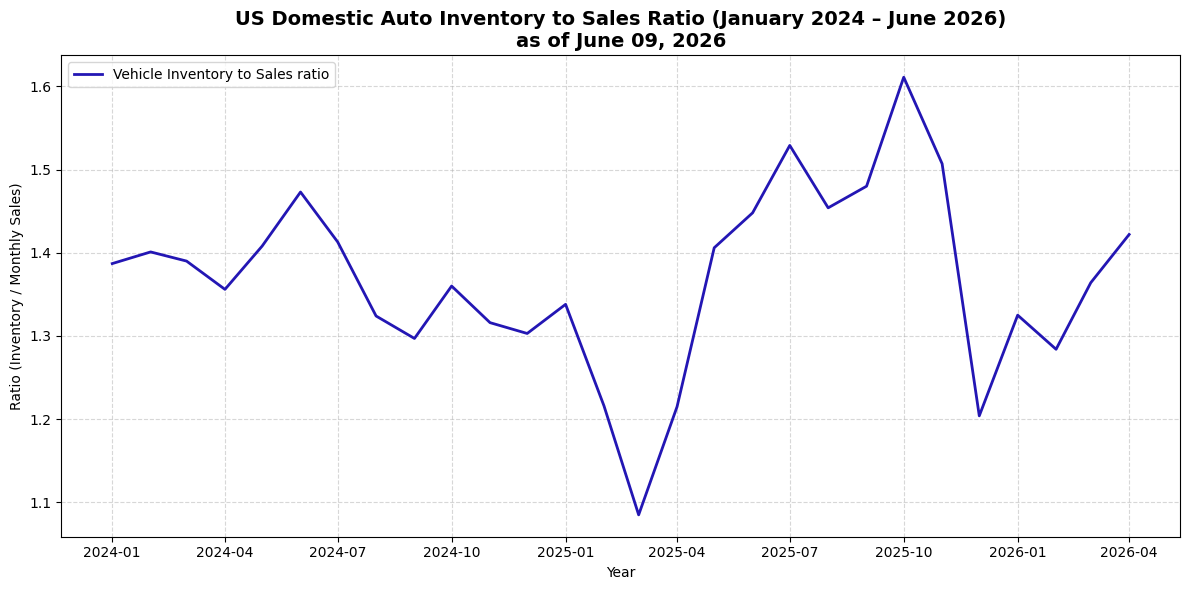

In [4]:
df = web.DataReader('AISRSA', 'fred', start, end)

# Plotting
plt.figure(figsize = (12, 6))
plt.plot(df.index, df["AISRSA"], label = 'Vehicle Inventory to Sales ratio', color = "#2316b4", linewidth = 2)

#plt.title(f'US Domestic Auto Inventory to Sales Ratio ({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize = 14, fontweight = 'bold')
plt.title(f'US Domestic Auto Inventory to Sales Ratio ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize = 14, fontweight = 'bold')
plt.xlabel('Year')
plt.ylabel('Ratio (Inventory / Monthly Sales)')

plt.grid(True, which = 'both', linestyle = '--', alpha = 0.5)
plt.legend()
plt.tight_layout()
    
plt.show()

### U.S. Domestic Vehicle Inventory vs. Monthly Moving Average (2024 - Present)

<Figure size 1600x600 with 0 Axes>

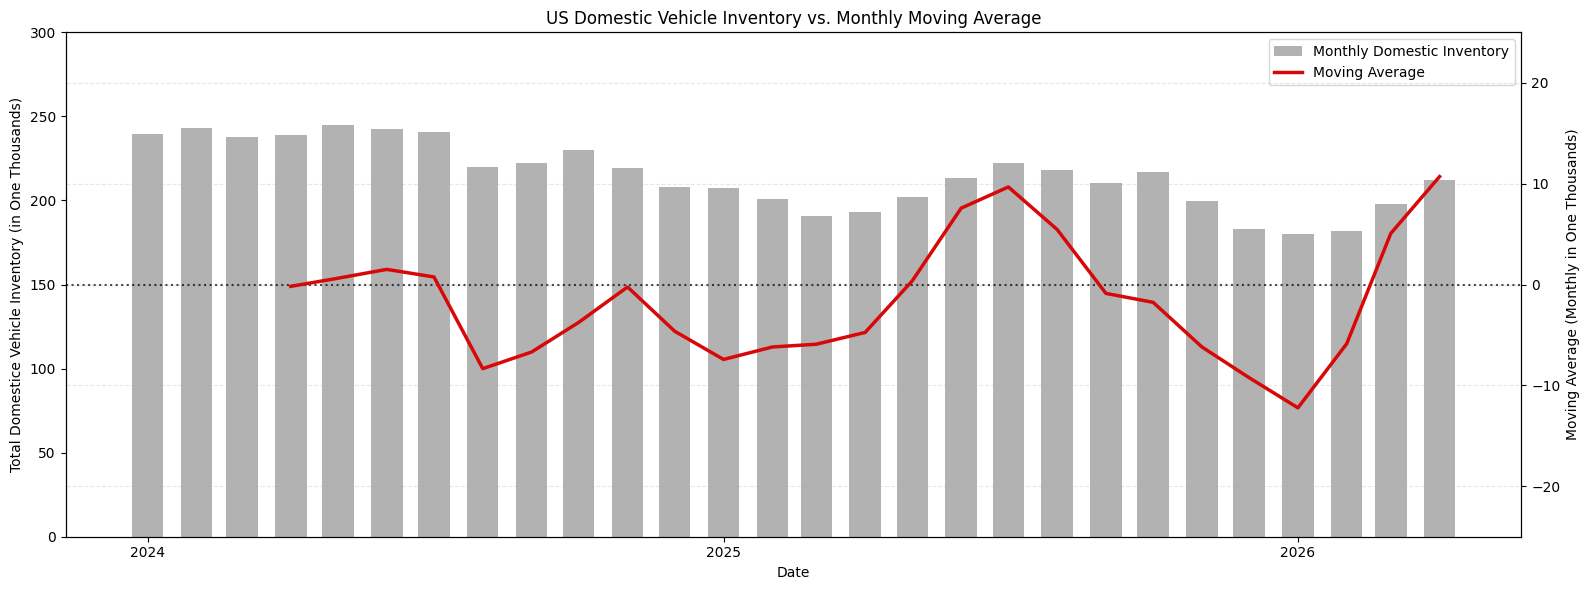

In [5]:
start = datetime(2024, 1, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(years=1)

# eda
df = web.DataReader("AUINSA", "fred", start, end)

df["domestic_inv"] = df["AUINSA"].diff()
df["ma_3"] = df["domestic_inv"].rolling(3).mean()

df_focus = df[(df.index >= start)]

plt.figure(figsize = (16, 6)) 

fig, ax1 = plt.subplots(figsize = (16, 6))

# inventory bar graph
ax1.set_xlabel("Date")
ax1.set_ylabel("Total Domestice Vehicle Inventory (in One Thousands)", color = "black")
ax1.tick_params(axis = "y", labelcolor = "black")
ax1.set_ylim(0, 300)
ax1.bar(
    df_focus.index,
    df_focus["AUINSA"],
    color = "grey",
    width = 20,
    alpha = 0.6,
    label = "Monthly Domestic Inventory",
)

# copy left axis
ax2 = ax1.twinx()

# inventory moving average
ax2.set_ylabel("Moving Average (Monthly in One Thousands)", color = "black")
ax2.tick_params(axis = "y", labelcolor = "black")
ax2.axhline(0, color = "black", linestyle = ":", linewidth = 1.5, alpha = 0.7)
ax2.set_ylim(-25, 25)
ax2.plot(
    df_focus.index,
    df_focus["ma_3"],
    color = "#d90808",
    linewidth = 2.5,
    label = "Moving Average",
)

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.title(  
    "US Domestic Vehicle Inventory vs. Monthly Moving Average"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = "upper right")

plt.grid(axis = "y", linestyle = "--", alpha = 0.3)
fig.tight_layout()

plt.show()


### U.S Total Domestic Vehicle Sales and Moving Average (Janaury 2024 - Present)

<Figure size 1600x600 with 0 Axes>

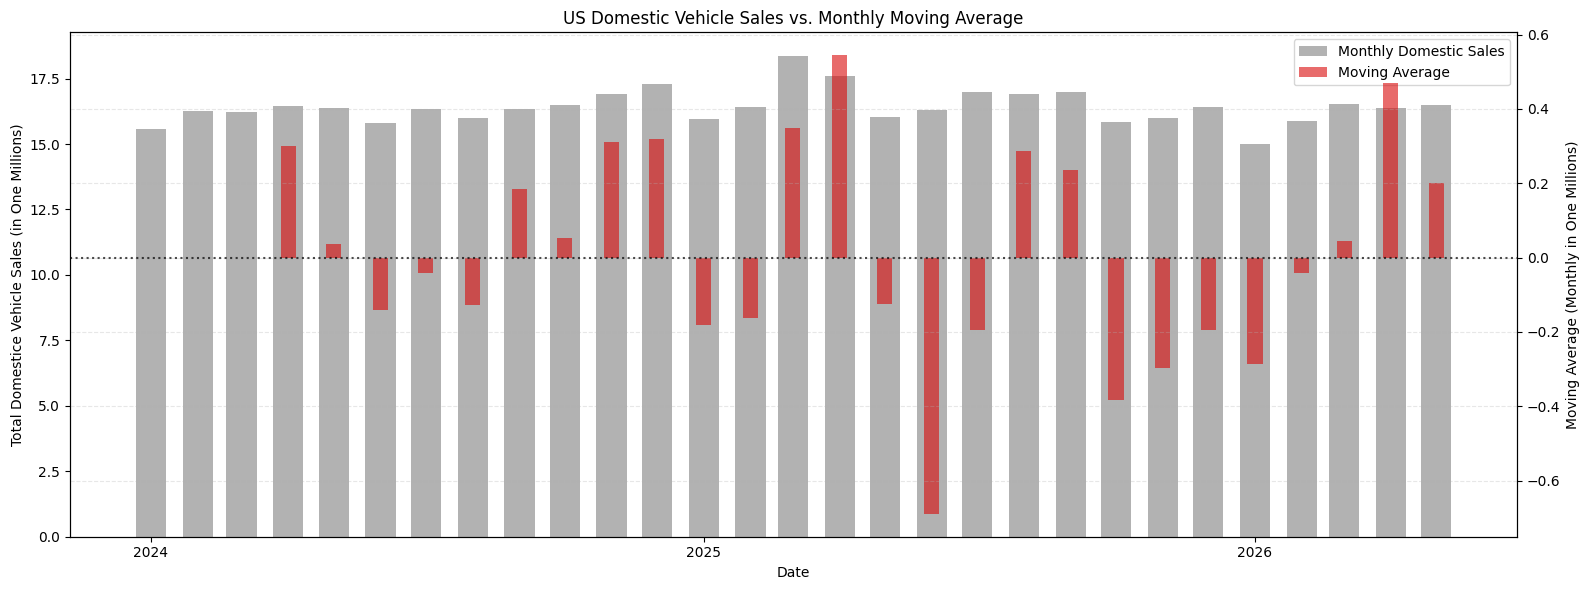

In [6]:
# eda
df = web.DataReader("TOTALSA", "fred", start, end)

df["salestot"] = df["TOTALSA"].diff()
df["ma_3"] = df["salestot"].rolling(3).mean()

df_focus = df[(df.index >= start)]

plt.figure(figsize = (16, 6)) 

fig, ax1 = plt.subplots(figsize = (16, 6))

# inventory bar graph
ax1.set_xlabel("Date")
ax1.set_ylabel("Total Domestice Vehicle Sales (in One Millions)", color = "black")
ax1.tick_params(axis = "y", labelcolor = "black")
#ax1.set_ylim(200000, 1600000)
ax1.bar(
    df_focus.index,
    df_focus["TOTALSA"],
    color = "grey",
    width = 20,
    alpha = 0.6,
    label = "Monthly Domestic Sales",
)

# copy left axis
ax2 = ax1.twinx()

# inventory moving average
ax2.set_ylabel("Moving Average (Monthly in One Millions)", color = "black")
ax2.tick_params(axis = "y", labelcolor = "black")
ax2.axhline(0, color = "black", linestyle = ":", linewidth = 1.5, alpha = 0.7)
ax2.bar(
    df_focus.index,
    df_focus["ma_3"],
    color = "#d90808",
    width = 10,
    alpha = 0.6,
    label = "Moving Average",
)

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.title(  
    "US Domestic Vehicle Sales vs. Monthly Moving Average"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = "upper right")

plt.grid(axis = "y", linestyle = "--", alpha = 0.3)
fig.tight_layout()

plt.show()


### U.S. New Vehicle Price Inflation (January 2025 - Present)

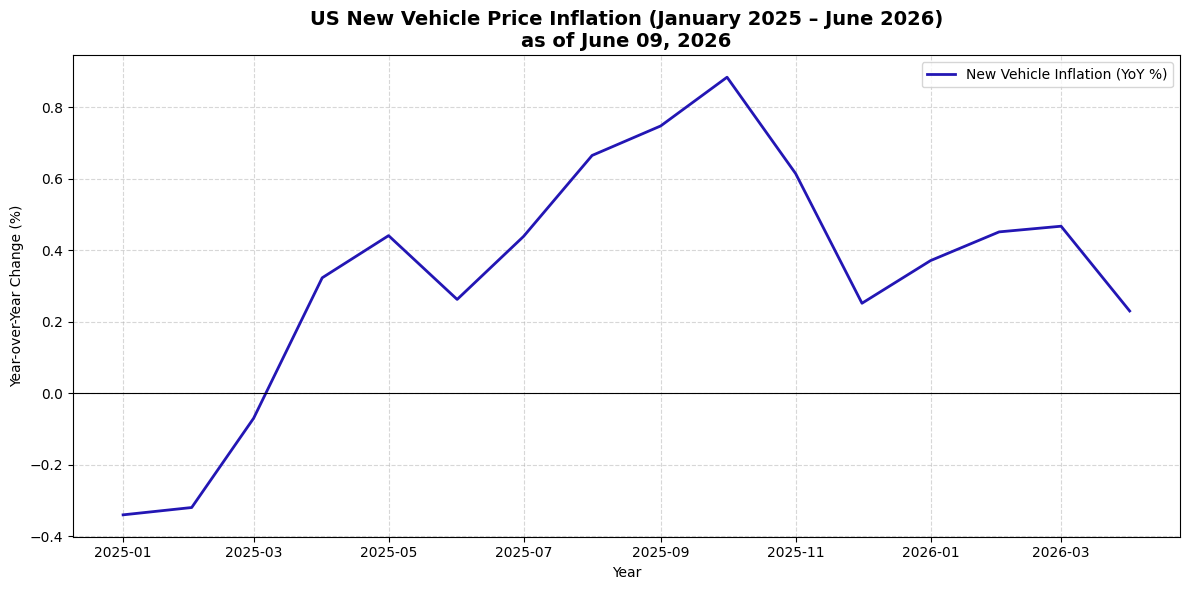

In [7]:
df_vehicle_cpi = web.DataReader('CUSR0000SETA01', 'fred', start, end)

df_yoy = df_vehicle_cpi.pct_change(periods = 12) * 100

# Plotting
plt.figure(figsize = (12, 6))

# Plotting df_yoy instead of raw index
plt.plot(df_yoy.index, df_yoy["CUSR0000SETA01"], label = 'New Vehicle Inflation (YoY %)', color = "#2316b4", linewidth = 2)


plt.title(f'US New Vehicle Price Inflation ({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize = 14, fontweight = 'bold')
plt.xlabel('Year')
plt.ylabel('Year-over-Year Change (%)') 

plt.axhline(0, color = 'black', linewidth = 0.8, linestyle = '-')
plt.grid(True, which = 'both', linestyle = '--', alpha = 0.5)
plt.legend()
plt.tight_layout()

plt.show()

# Conclusions and Observations

***In progress***

## Update Schedule
### TBA

#### ***Review and analysis publishing on Friday, -----, 2026, at 1:30 P.M. Pacific Time.***